# Dans ce pipeline, je me concentre sur le résultat obtenu. La seule différence par rapport au premier pipeline est l’utilisation de SpaCy pour la lemmatisation.

In [1]:
import pandas as pd
import regex as re
import contractions

In [2]:
raw = pd.read_csv("../IMDB Dataset.csv")
raw = raw.drop_duplicates(subset='review', keep='first')
cleaning = raw.copy()

In [3]:
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"<.*?>", "", x))
cleaning["review"] = cleaning["review"].apply(lambda x: x.lower())
cleaning["review"] = cleaning["review"].apply(lambda x: contractions.fix(x))
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"[^\w\s]", " ", x))
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

cleaning["tokens"] = cleaning["review"].apply(lambda x: x.split())

STOPWORDS = set(stopwords.words('english'))
cleaning['tokens'] = cleaning['tokens'].apply(lambda x: [token for token in x if token not in STOPWORDS])

lemmatizer = WordNetLemmatizer()
cleaning["final_nltk"] = cleaning['tokens'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x]))

[nltk_data] Downloading package stopwords to /home/abood/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/abood/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
import spacy
nlp = spacy.load("en_core_web_sm")

cleaning["final_spacy"] = cleaning["review"].apply(lambda x: " ".join(token.lemma_ for token in nlp(x)))

premier observation lemmatization avec SpaCy c'est qu'elle prend beaucoup plus de temps.

In [6]:
cleaning["label"] = cleaning["sentiment"] == "positive"

In [7]:
cleaning

,review,sentiment,tokens,final_nltk,final_spacy,label
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",one reviewer mentioned watching 1 oz episode h...,one of the other reviewer have mention that af...,True
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,a wonderful little production the filming tech...,True
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,I think this be a wonderful way to spend time ...,True
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,...",basically family little boy jake think zombie ...,basically there be a family where a little boy...,False
4,petter mattei s love in the time of money is a...,positive,"[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...,petter mattei s love in the time of money be a...,True
...,...,...,...,...,...,...
49995,i thought this movie did a down right good job...,positive,"[thought, movie, right, good, job, creative, o...",thought movie right good job creative original...,I think this movie do a down right good job it...,True
49996,bad plot bad dialogue bad acting idiotic direc...,negative,"[bad, plot, bad, dialogue, bad, acting, idioti...",bad plot bad dialogue bad acting idiotic direc...,bad plot bad dialogue bad acting idiotic direc...,False
49997,i am a catholic taught in parochial elementary...,negative,"[catholic, taught, parochial, elementary, scho...",catholic taught parochial elementary school nu...,I be a catholic teach in parochial elementary ...,False
49998,i am going to have to disagree with the previo...,negative,"[going, disagree, previous, comment, side, mal...",going disagree previous comment side maltin on...,I be go to have to disagree with the previous ...,False


In [8]:
cleaned = cleaning[["final_nltk", "final_spacy", "label"]].copy()

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_spacy = CountVectorizer(min_df=3) # On ignore les mots rares, on prend juste qui apparait plus que 3 fois
bow_matrix_spacy = vectorizer_spacy.fit_transform(cleaned['final_spacy'])

In [10]:
print(bow_matrix_spacy.shape)

(49582, 38031)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_train_spacy, X_test_spacy, y_train_spacy, y_test_spacy = train_test_split(bow_matrix_spacy, cleaned['label'], test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear', verbose=True)
svm_model.fit(X_train_spacy, y_train_spacy)

[LibSVM]..................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................*.............................................................................................................................................................................

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,True


ce modèle a pris 3h 53m pour s'entrainer.

In [13]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Predictions
y_pred_spacy = svm_model.predict(X_test_spacy)

# Accuracy
print("Accuracy:", accuracy_score(y_test_spacy, y_pred_spacy))

# Detailed metrics
print("\nClassification Report:\n", classification_report(y_test_spacy, y_pred_spacy))

Accuracy: 0.8551981446001815

Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.85      0.85      4939
        True       0.85      0.86      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



Le résultat obtenu est presque le même que celui du premier pipeline, mais il a demandé beaucoup plus de temps.

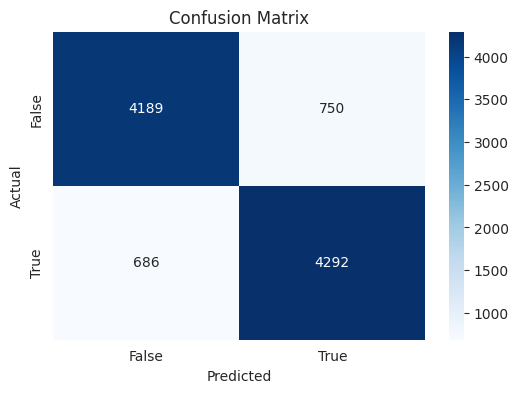

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_spacy, y_pred_spacy)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(cleaned['label'].unique()),
            yticklabels=sorted(cleaned['label'].unique()))

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
import joblib

# Save model
joblib.dump(svm_model, "../svm_bow_spacy_model.pkl")

# Save the CountVectorizer too (needed for new predictions)
joblib.dump(vectorizer_spacy, "../countvectorizer_spacy.pkl")

['countvectorizer_spacy.pkl']

In [2]:
svm_model = joblib.load("../svm_bow_model.pkl")
vectorizer = joblib.load("../countvectorizer.pkl")

# Example prediction
new_text = ["I love this movie"]
new_bow = vectorizer.transform(new_text)
pred = svm_model.predict(new_bow)
print(pred)

[ True]
